#  Apple Prices <hr style="border:2.5px solid #fa6194ff"></hr>

<b> Elyssa Tombale </b>
<br>T09-A</br>

In [50]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [51]:
# load dataset
df = pd.read_csv(r"apple_prices_dataset.csv",
                 delimiter=",")
df

,Record_ID,Date,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
0,1,2024-11-27,Brazil,Gala,Premium,Supermarket,4.31,858,3697.98
1,2,2025-01-09,Japan,Fuji,Premium,Supermarket,2.96,1913,5662.48
2,3,2025-03-20,Canada,Red Delicious,Standard,Supermarket,2.35,542,1273.70
3,4,2025-08-02,Brazil,Golden Delicious,Economy,Supermarket,1.26,507,638.82
4,5,2025-08-13,Germany,Gala,Economy,Wholesale Market,2.97,151,448.47
...,...,...,...,...,...,...,...,...,...
495,496,2024-04-01,China,Granny Smith,Premium,Wholesale Market,4.42,1792,7920.64
496,497,2025-01-16,Australia,Pink Lady,Economy,Online Store,0.81,1772,1435.32
497,498,2024-05-26,USA,Red Delicious,Economy,Online Store,1.85,1405,2599.25
498,499,2024-12-12,Brazil,Pink Lady,Premium,Wholesale Market,1.03,68,70.04


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         500 non-null    int64  
 1   Date              500 non-null    object 
 2   Country           500 non-null    object 
 3   Apple_Variety     500 non-null    object 
 4   Quality_Grade     500 non-null    object 
 5   Market_Type       500 non-null    object 
 6   Price_per_KG_USD  500 non-null    float64
 7   Quantity_Sold_KG  500 non-null    int64  
 8   Revenue_USD       500 non-null    float64
dtypes: float64(2), int64(2), object(5)
memory usage: 35.3+ KB


In [53]:
df.describe()

,Record_ID,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2.674440,1020.458000,2661.852900
std,144.481833,1.069996,578.570393,1887.389644
min,1.000000,0.810000,50.000000,49.500000
25%,125.750000,1.740000,511.250000,1165.857500
50%,250.500000,2.685000,1044.000000,2330.265000
75%,375.250000,3.602500,1534.250000,3840.607500
max,500.000000,4.490000,1999.000000,8461.560000


In [54]:
numeric_cols = ['Price_per_KG_USD','Quantity_Sold_KG','Revenue_USD']

means_data = {col: [] for col in numeric_cols}

np.random.seed(42)

for _ in range(50):  # 50 samples
    for col in numeric_cols:
        sample = np.random.choice(df[col], size=30, replace=True)
        means_data[col].append(np.mean(sample))

df_means = pd.DataFrame(means_data)
df_means

,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
0,2.952667,846.266667,2865.544667
1,2.627333,1049.500000,2162.309667
2,2.685333,1009.833333,2991.826333
3,2.673667,959.233333,2738.234333
4,2.518667,1090.133333,2313.336667
5,2.574667,1263.300000,2458.215000
6,2.623667,1025.766667,2882.218000
7,2.668667,1022.166667,2342.450000
8,2.529000,959.533333,2674.066333
9,2.628667,924.433333,3255.078333


In [55]:
#CLT Dataset
df_means.to_csv("apple_clt_dataset.csv", index=False)

In [56]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Record_ID         500 non-null    int64  
 1   Date              500 non-null    object 
 2   Country           500 non-null    object 
 3   Apple_Variety     500 non-null    object 
 4   Quality_Grade     500 non-null    object 
 5   Market_Type       500 non-null    object 
 6   Price_per_KG_USD  500 non-null    float64
 7   Quantity_Sold_KG  500 non-null    int64  
 8   Revenue_USD       500 non-null    float64
dtypes: float64(2), int64(2), object(5)
memory usage: 35.3+ KB


In [57]:
df.describe()

,Record_ID,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
count,500.000000,500.000000,500.000000,500.000000
mean,250.500000,2.674440,1020.458000,2661.852900
std,144.481833,1.069996,578.570393,1887.389644
min,1.000000,0.810000,50.000000,49.500000
25%,125.750000,1.740000,511.250000,1165.857500
50%,250.500000,2.685000,1044.000000,2330.265000
75%,375.250000,3.602500,1534.250000,3840.607500
max,500.000000,4.490000,1999.000000,8461.560000


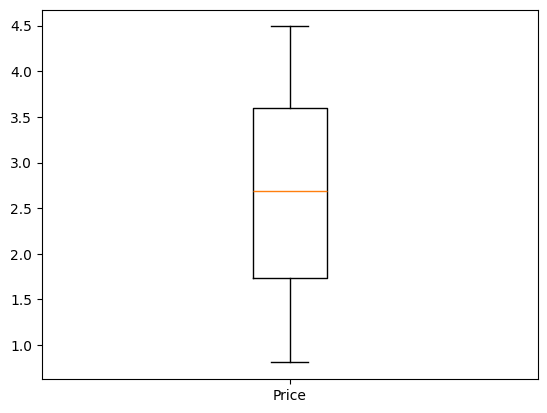

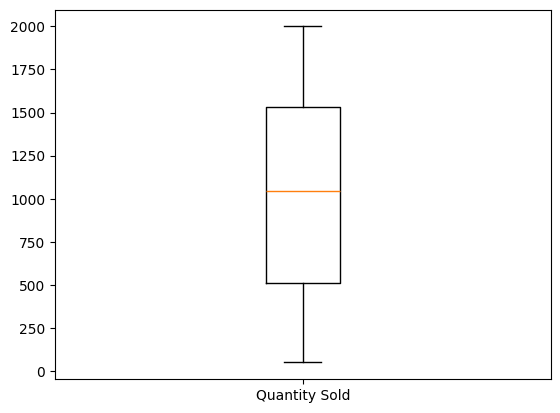

In [58]:
#Outlier Detection
plt.boxplot(df['Price_per_KG_USD'], tick_labels=['Price'])
plt.show()

plt.boxplot(df['Quantity_Sold_KG'], tick_labels=['Quantity Sold'])
plt.show()

In [59]:
#Removing 3 Sigma Outliers
z_price = stats.zscore(df['Price_per_KG_USD'])
price_outliers = (z_price < -3) | (z_price > 3)
df = df[~price_outliers]

z_quantity = stats.zscore(df['Quantity_Sold_KG'])
quantity_outliers = (z_quantity < -3) | (z_quantity > 3)
df = df[~quantity_outliers]

In [60]:
#Save Clean Dataset
df.to_csv("apple_cleaned_dataset.csv", index=False)

In [61]:
#Load Dataset
df = pd.read_csv("apple_cleaned_dataset.csv")
df

,Record_ID,Date,Country,Apple_Variety,Quality_Grade,Market_Type,Price_per_KG_USD,Quantity_Sold_KG,Revenue_USD
0,1,2024-11-27,Brazil,Gala,Premium,Supermarket,4.31,858,3697.98
1,2,2025-01-09,Japan,Fuji,Premium,Supermarket,2.96,1913,5662.48
2,3,2025-03-20,Canada,Red Delicious,Standard,Supermarket,2.35,542,1273.70
3,4,2025-08-02,Brazil,Golden Delicious,Economy,Supermarket,1.26,507,638.82
4,5,2025-08-13,Germany,Gala,Economy,Wholesale Market,2.97,151,448.47
...,...,...,...,...,...,...,...,...,...
495,496,2024-04-01,China,Granny Smith,Premium,Wholesale Market,4.42,1792,7920.64
496,497,2025-01-16,Australia,Pink Lady,Economy,Online Store,0.81,1772,1435.32
497,498,2024-05-26,USA,Red Delicious,Economy,Online Store,1.85,1405,2599.25
498,499,2024-12-12,Brazil,Pink Lady,Premium,Wholesale Market,1.03,68,70.04


In [62]:
#Descriptive Statistics
df[['Price_per_KG_USD','Quantity_Sold_KG']].describe()

,Price_per_KG_USD,Quantity_Sold_KG
count,500.000000,500.000000
mean,2.674440,1020.458000
std,1.069996,578.570393
min,0.810000,50.000000
25%,1.740000,511.250000
50%,2.685000,1044.000000
75%,3.602500,1534.250000
max,4.490000,1999.000000


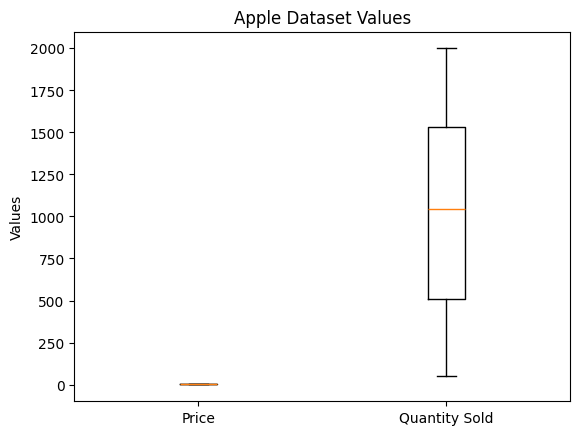

In [63]:
#Boxplot Comparison
plt.boxplot(df[['Price_per_KG_USD','Quantity_Sold_KG']],
            tick_labels=['Price','Quantity Sold'])

plt.title("Apple Dataset Values")
plt.ylabel("Values")
plt.show()

In [64]:
#Shapiro-Wilk Normality Test
alpha = 0.05

print("Price:")
w_stat, p_value = stats.shapiro(df['Price_per_KG_USD'])
print("W:", w_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")


print("\nQuantity Sold:")
w_stat, p_value = stats.shapiro(df['Quantity_Sold_KG'])
print("W:", w_stat)
print("P-value:", p_value)

if p_value < alpha:
    print("Non-normal data")
else:
    print("Normal data")

Price:
W: 0.9540220516154688
P-value: 2.299604594122254e-11
Non-normal data

Quantity Sold:
W: 0.9469230023217108
P-value: 2.1264500456995136e-12
Non-normal data


In [65]:
#F-Test for Equality of Variances
var_price = df['Price_per_KG_USD'].var(ddof=1)
var_quantity = df['Quantity_Sold_KG'].var(ddof=1)

if var_price > var_quantity:
    f_stat = var_price / var_quantity
else:
    f_stat = var_quantity / var_price

print("F-stat:", f_stat)

dof_p = df['Price_per_KG_USD'].count() - 1
dof_q = df['Quantity_Sold_KG'].count() - 1

p_value = 1 - stats.f.cdf(f_stat, dof_p, dof_q)
print("p-value:", p_value)

if p_value < alpha:
    print("Unequal variances")
else:
    print("Equal variances")

F-stat: 292380.0339456301
p-value: 1.1102230246251565e-16
Unequal variances


In [66]:
#2-Sample T-Test
t_stat, p_value = stats.ttest_ind(
    df['Price_per_KG_USD'],
    df['Quantity_Sold_KG'],
    alternative='greater',
    equal_var=True
)

print("t_stat:", t_stat)
print("p_value:", p_value)

if p_value < alpha:
    print("Price values are higher.")
else:
    print("No significant difference.")

t_stat: -39.33539224004748
p_value: 1.0
No significant difference.


In [67]:
#Cohen's d
price_mean = df['Price_per_KG_USD'].mean()
quantity_mean = df['Quantity_Sold_KG'].mean()

price_std = df['Price_per_KG_USD'].std(ddof=1)

d = abs((price_mean - quantity_mean) / price_std)

print("Cohen's d:", d)

Cohen's d: 951.202716259525


In [68]:
#Power of the Test
power = TTestPower().power(
    effect_size=-d,
    nobs=df['Price_per_KG_USD'].count(),
    alpha=0.05,
    alternative="smaller"
)

print("Power of the test:", power*100, "%")

Power of the test: 100.0 %
